In [1]:
# Importation de la bibliothèque pandas pour la manipulation des données
import pandas as pd

# Définition des noms de colonnes selon la documentation UCI
noms_colonnes = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Chargement du dataset avec gestion des valeurs manquantes représentées par '?'
chemin_fichier = "../data/processed.cleveland.data"
dataset = pd.read_csv(
    chemin_fichier, 
    names=noms_colonnes, 
    header=None, 
    na_values='?'
)

# Suppression des lignes contenant des valeurs manquantes
dataset_propre = dataset.dropna()

# Vérification des dimensions du dataset après nettoyage
print("Dimensions initiales :", dataset.shape)
print("Dimensions après nettoyage :", dataset_propre.shape)
print("\nValeurs manquantes après nettoyage :")
print(dataset_propre.isna().sum())

# Sauvegarde du dataset nettoyé pour les étapes suivantes
dataset_propre.to_csv("../data/cleveland_clean.csv", index=False)

Dimensions initiales : (303, 14)
Dimensions après nettoyage : (297, 14)

Valeurs manquantes après nettoyage :
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


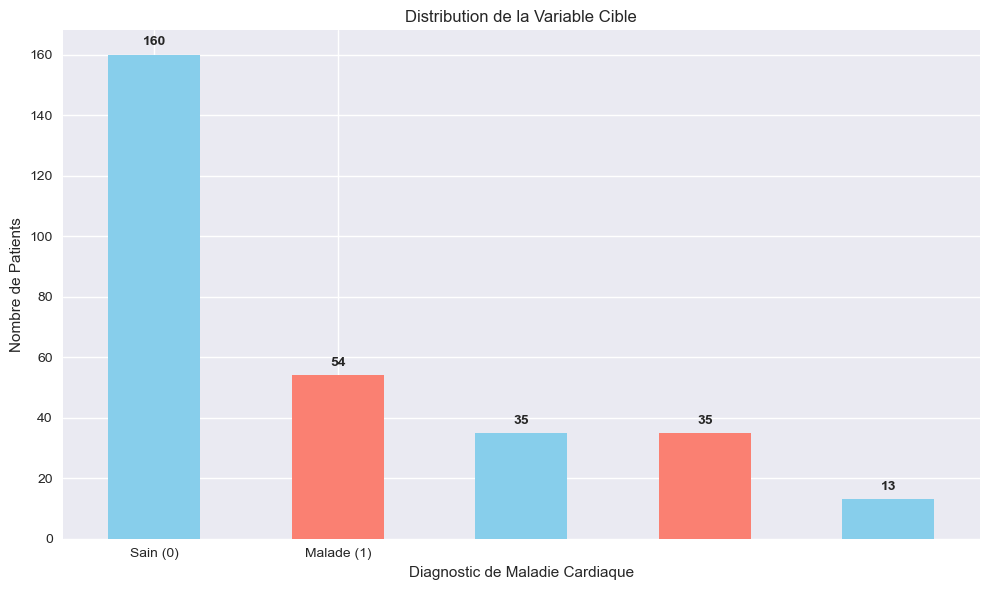

c:\Users\HP Elitebook\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\HP Elitebook\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\HP Elitebook\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\HP Elitebook\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

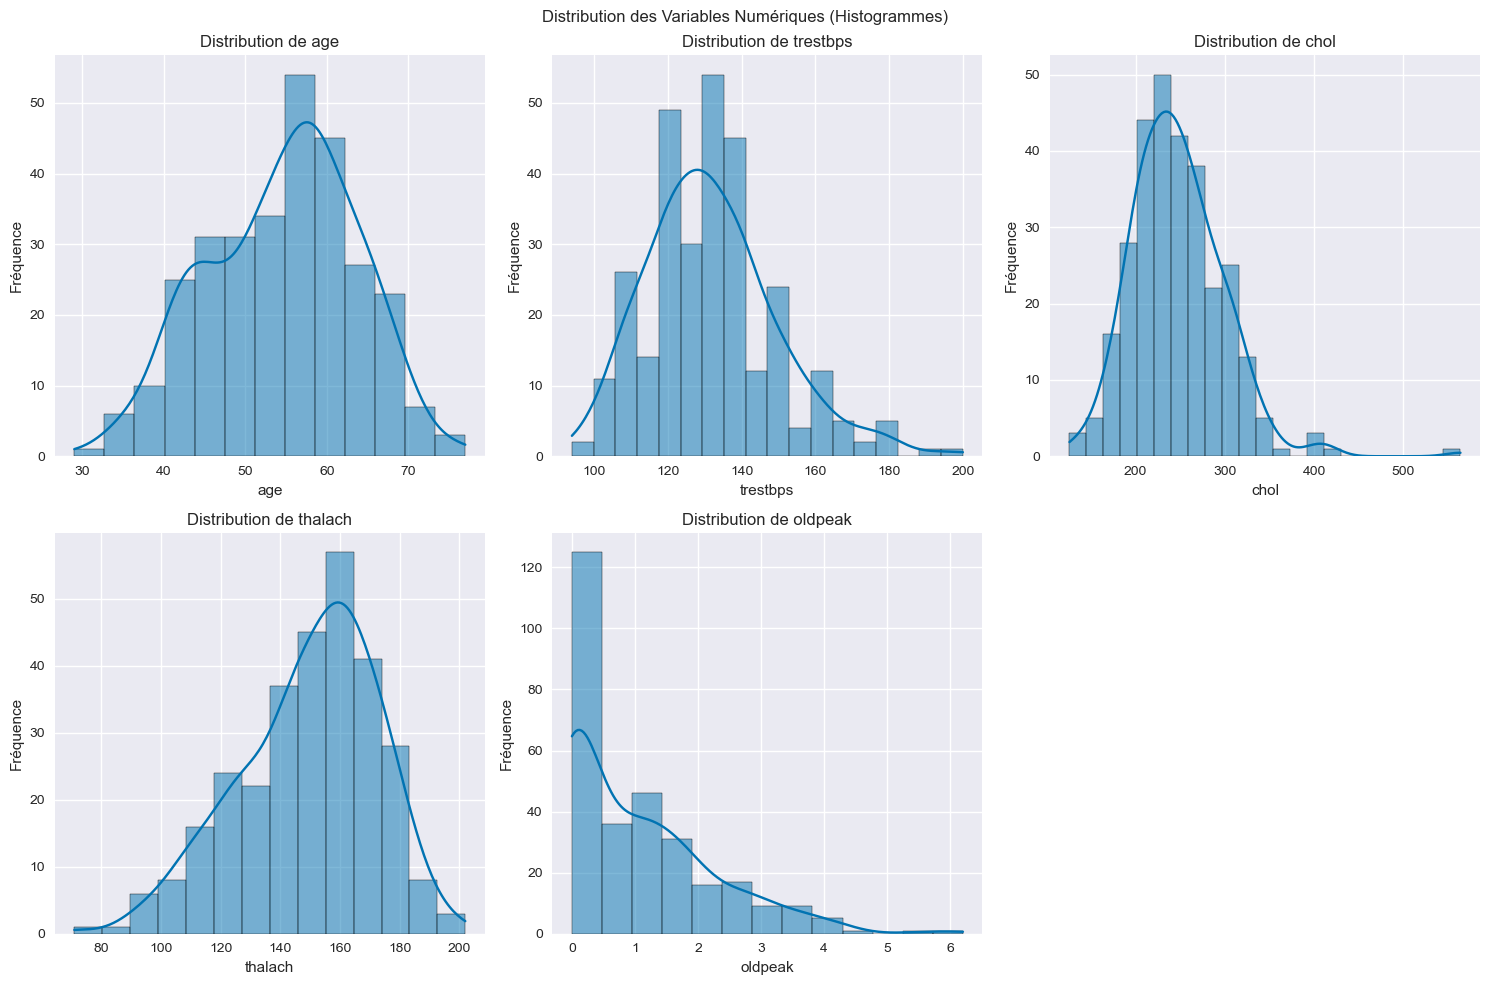

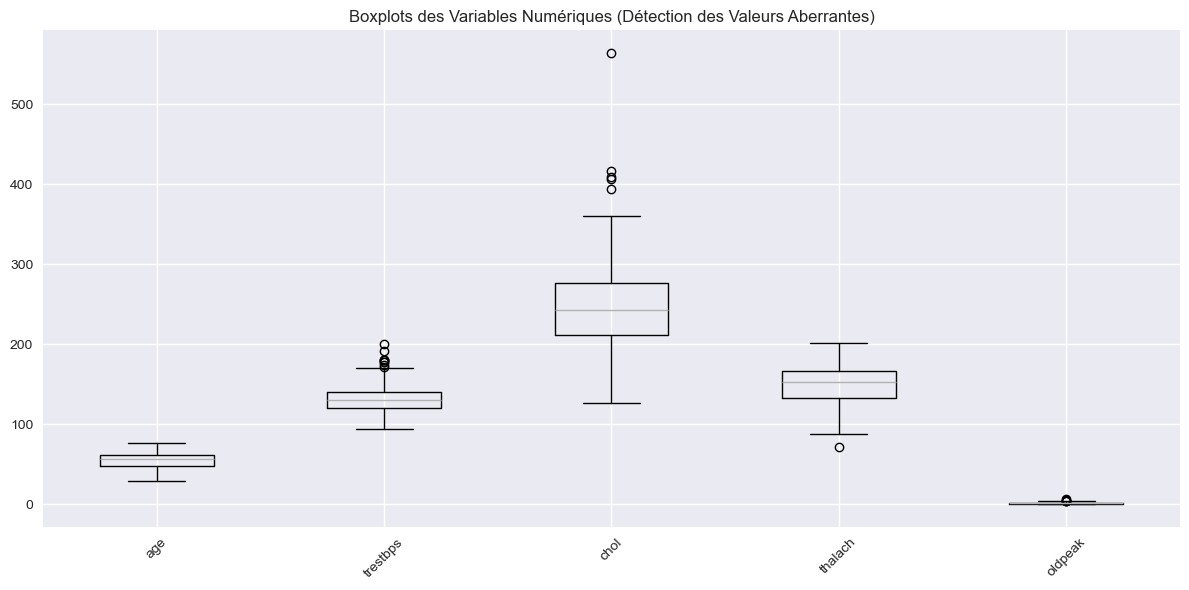

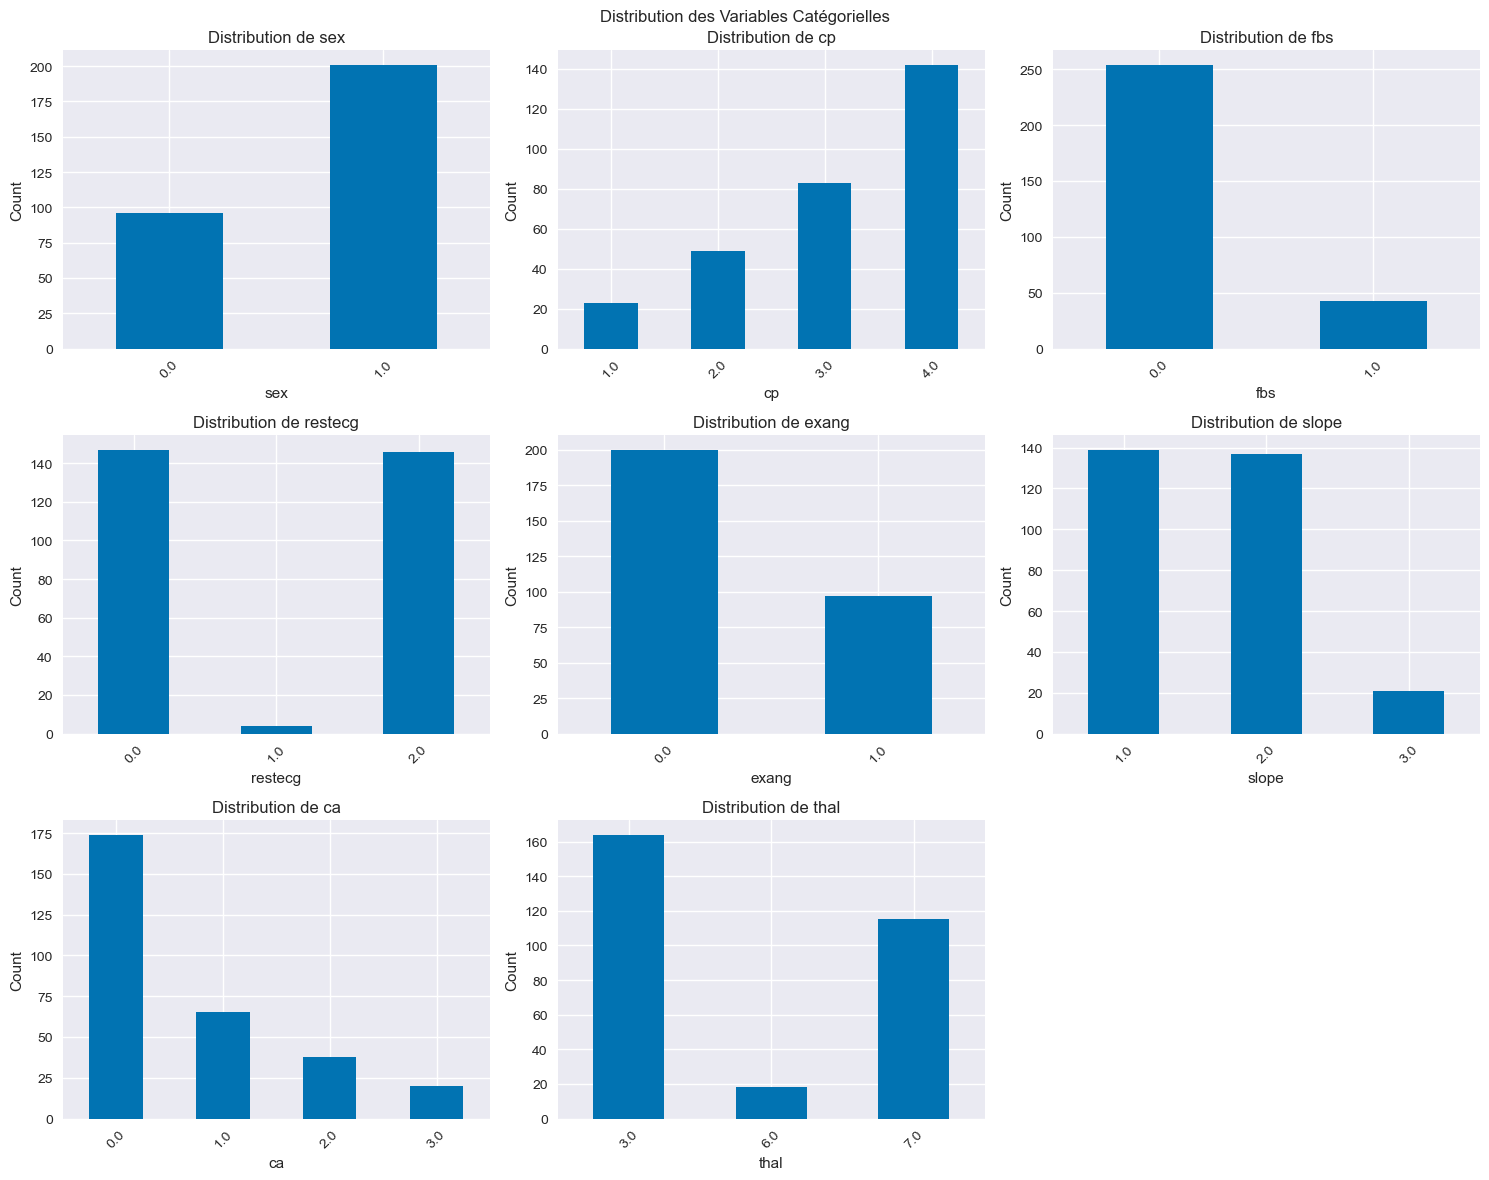

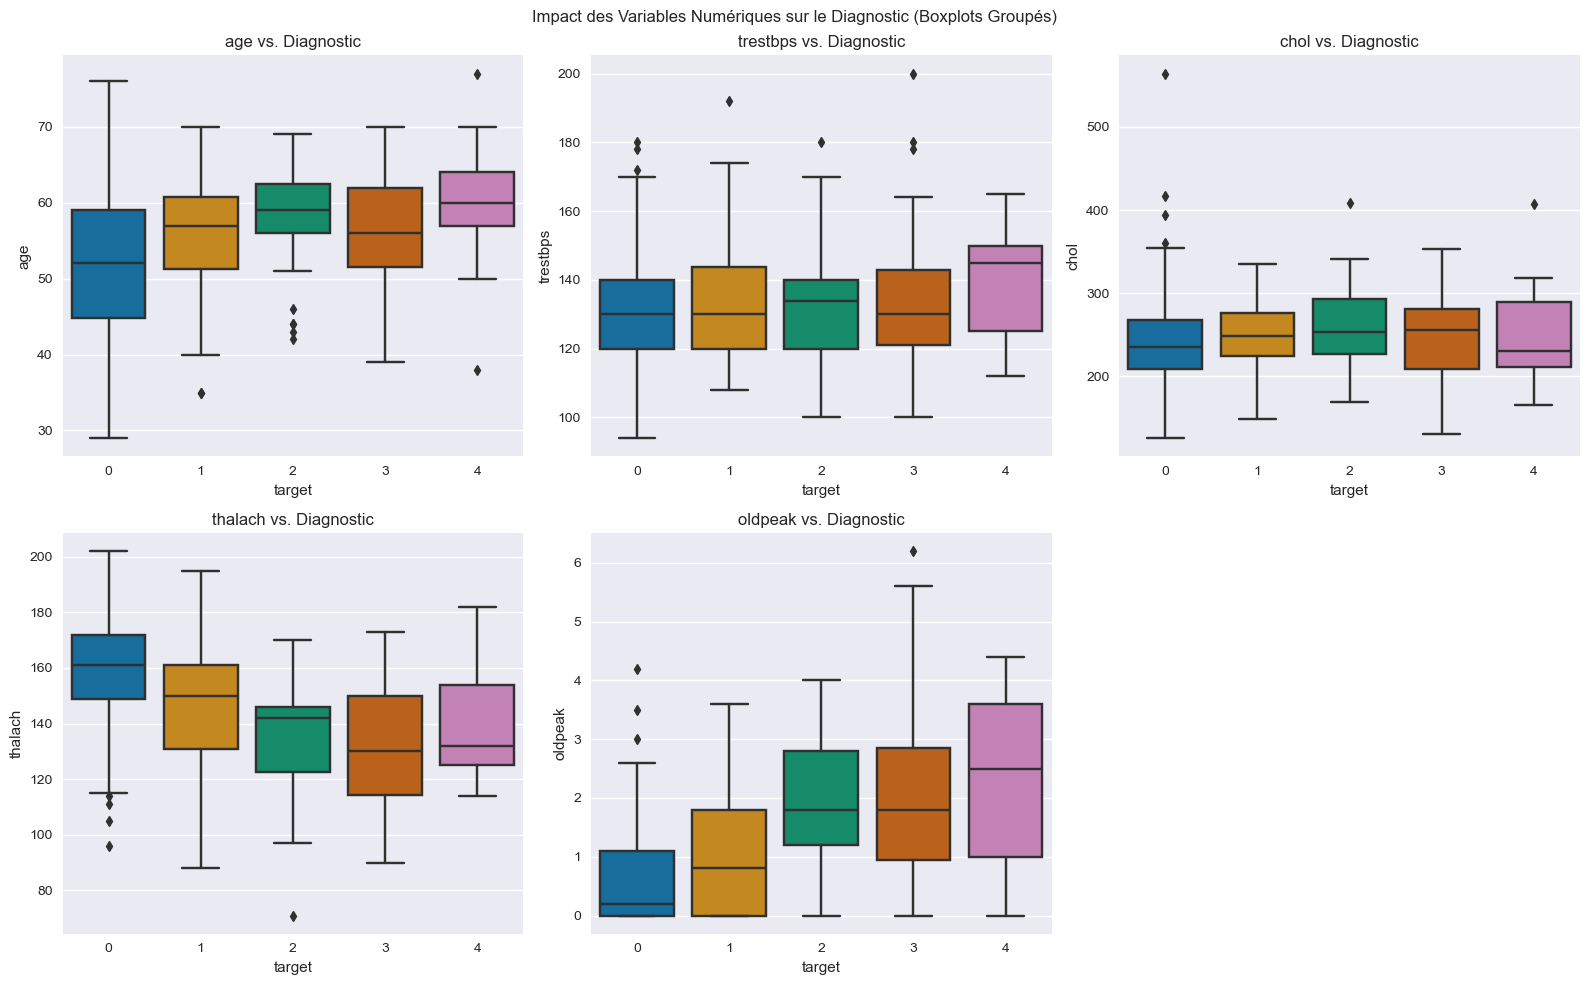

AttributeError: 'numpy.int64' object has no attribute 'startswith'

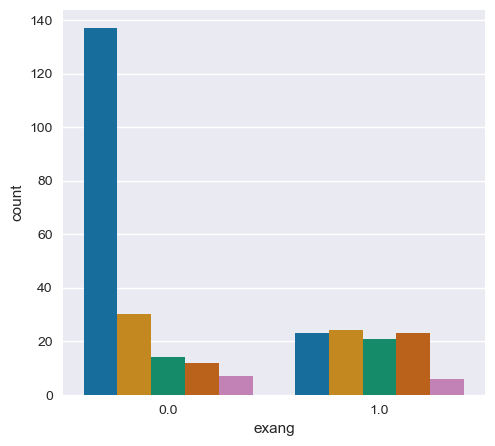

In [1]:
# Importations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Charger les données nettoyées
df = pd.read_csv('../data/cleveland_clean.csv')

# Configuration de l'affichage
plt.style.use('seaborn-v0_8') # Thème visuel propre
sns.set_palette("colorblind") # Palette de couleurs adaptée aux daltoniens
plt.rcParams['figure.figsize'] = (10, 6) # Taille par défaut des figures

# %% 1. ANALYSE UNIVARIEE

# 1.a) Distribution de la Variable Cible
plt.figure()
ax = df['target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution de la Variable Cible')
plt.xlabel('Diagnostic de Maladie Cardiaque')
plt.ylabel('Nombre de Patients')
plt.xticks(ticks=[0, 1], labels=['Sain (0)', 'Malade (1)'], rotation=0)

# Ajouter les nombres au-dessus des barres
for i, v in enumerate(df['target'].value_counts().sort_index()):
    ax.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 1.b) Distribution des Variables Numériques
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # 2 lignes, 3 colonnes
axes = axes.ravel() # Applatir le tableau d'axes pour une boucle facile

for i, col in enumerate(num_features):
    # Histogramme avec courbe de densité
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

# Cacher le dernier axe vide s'il y a 5 variables sur 6 plots
if len(num_features) < 6:
    axes[-1].set_visible(False)

plt.suptitle('Distribution des Variables Numériques (Histogrammes)')
plt.tight_layout()
plt.show()

# 1.c) Boxplots pour voir les outliers
plt.figure(figsize=(12, 6))
df[num_features].boxplot()
plt.title('Boxplots des Variables Numériques (Détection des Valeurs Aberrantes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 1.d) Distribution des Variables Catégorielles
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # 3x3 grid
axes = axes.ravel()

for i, col in enumerate(cat_features):
    df[col].value_counts().sort_index().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45) # Incliner les labels

# Cacher les axes non utilisés
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des Variables Catégorielles')
plt.tight_layout()
plt.show()

# %% 2. ANALYSE BIVARIEE

# 2.a) Relation Variables Numériques / Target (Boxplots Groupés)
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs. Diagnostic')
plt.suptitle('Impact des Variables Numériques sur le Diagnostic (Boxplots Groupés)')
plt.tight_layout()
plt.show()

# 2.b) Relation Variables Catégorielles / Target (Barres Groupées)
# Exemple pour 'exang' et 'cp'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='exang', hue='target', data=df)
plt.title('Prévalence de la maladie par Angine à l\'effort (exang)')
plt.xlabel('Angine à l\'effort')
plt.legend(title='Diagnostic', labels=['Sain', 'Malade'])

plt.subplot(1, 2, 2)
sns.countplot(x='cp', hue='target', data=df)
plt.title('Prévalence de la maladie par Type de Douleur (cp)')
plt.xlabel('Type de Douleur Thoracique')
plt.legend(title='Diagnostic', labels=['Sain', 'Malade'])

plt.tight_layout()
plt.show()

# %% 3. ANALYSE MULTIVARIEE : MATRICE DE CORRELATION

# Calcul de la matrice de corrélation
corr_matrix = df.corr(numeric_only=True)

# Masquer le triangle supérieur pour plus de clarté
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title('Matrice de Corrélation (Triangle Inférieur)')
plt.tight_layout()
plt.show()

# %% 4. SYNTHESE AUTOMATIQUE (Bonus Utile)
print("\n" + "="*50)
print("SYNTHÈSE RAPIDE DE L'EDA")
print("="*50)
print(f"Taille du dataset : {df.shape}")
print(f"\nDistribution de la cible :")
print(df['target'].value_counts())
print(f"\nValeurs manquantes :")
print(df.isnull().sum())
print(f"\nCorrélations avec la cible :")
print(corr_matrix['target'].sort_values(ascending=False))